In [ ]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import numpy as np
import functools
from scipy.fft import fft, fftfreq
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

In [ ]:
def sigmoid(x, theta, a):
  return 1/(1 + np.exp(-a*(x-theta))) - 1/(1 + np.exp(a*theta))

def wilson_cowan(t, y, r_e, r_i, a_e, a_i, theta_e, theta_i, c1, c2, c3, c4, P, Q, tau = 1, k_e = 1, k_i = 1):
  I, E = y
  sigmoid_e = sigmoid(c1 * E - c2 * I + P, theta = theta_e, a = a_e)
  sigmoid_i = sigmoid(c3 * E - c4 * I + Q, theta = theta_i, a = a_i)

  dE = (-E + (k_e - r_e * E) * sigmoid_e) / tau
  dI = (-I + (k_i - r_i * I) * sigmoid_i) / tau
  return dI, dE

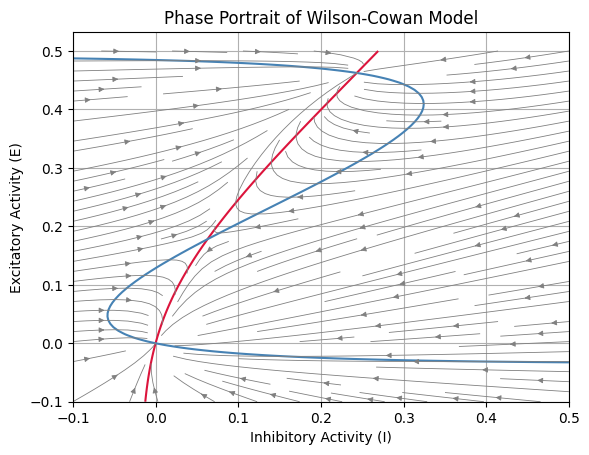

In [ ]:
#THEOREM 1

wc_parameters_1 = dict(r_e = 1, r_i = 1, a_e = 1.2, a_i = 1, theta_e = 2.8, theta_i = 4, c1 = 12, c2 = 4, c3 = 13, c4 = 11, P = 0, Q = 0)

E_points = np.linspace(-0.1, 0.5, 100)
I_points = np.linspace(-0.1, 0.5, 100)
I_grid, E_grid = np.meshgrid(I_points, E_points)

dI_grid, dE_grid = np.zeros_like(I_grid), np.zeros_like(I_grid)

for idx_1, I in enumerate(I_points):
  for idx_2, E in enumerate(E_points):

    dI, dE = wilson_cowan(0, [I, E], **wc_parameters_1)
    dI_grid[idx_2, idx_1], dE_grid[idx_2, idx_1] = dI, dE



fig, ax = plt.subplots()
ax.contour(I_grid, E_grid, dI_grid, levels = [0], colors = 'crimson')
ax.contour(I_grid, E_grid, dE_grid, levels = [0], colors = 'steelblue')
ax.streamplot(I_grid, E_grid, dI_grid, dE_grid, color='gray', density=1.2, linewidth=0.6, arrowsize=0.8)
plt.title('Phase Portrait of Wilson-Cowan Model')
plt.xlabel('Inhibitory Activity (I)')
plt.ylabel('Excitatory Activity (E)')
plt.grid(True)
plt.show()

/tmp/ipykernel_4496/941375519.py:14: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_1), [i, e], full_output=False)
/tmp/ipykernel_4496/941375519.py:14: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_1), [i, e], full_output=False)
/tmp/ipykernel_4496/1407657938.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-a*(x-theta))) - 1/(1 + np.exp(a*theta))
/tmp/ipykernel_4496/941375519.py:14: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_1), [i, e], full_output=False)


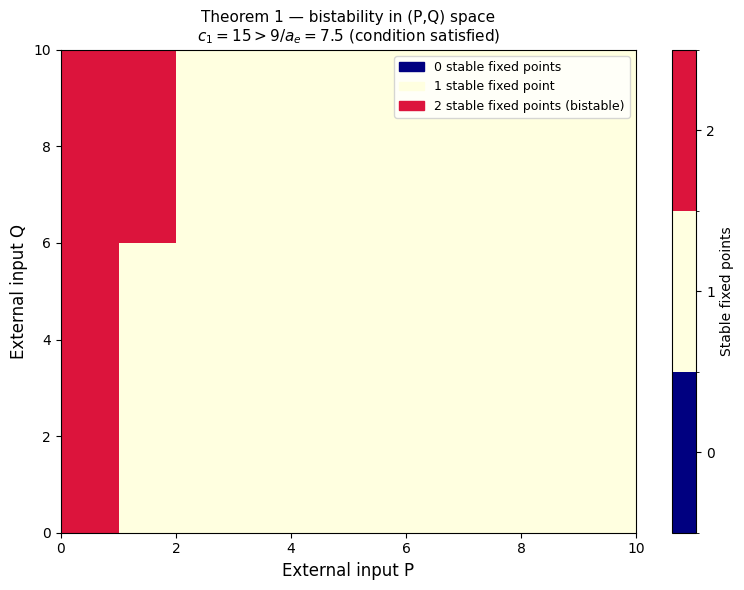

In [ ]:
c1_fixed = 15
final_parameters_1 = dict(r_e = 1, r_i = 1, a_e = 1.2, a_i = 1, theta_e = 2.8, theta_i = 4, c1 = c1_fixed, c2 = 4, c3 = 13, c4 = 11)
P = np.linspace(0, 10, 10)
Q = np.linspace(0, 10, 10)

E_values = np.linspace(0.01, 0.99, 100)
I_values = np.linspace(0.01, 0.99, 100)

def final_1(P, Q):
  fp = []

  for i in I_values:
    for e in E_values:
      sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_1), [i, e], full_output=False)
      check = wilson_cowan(0, sol, P=P, Q=Q, **final_parameters_1)

      if np.max(np.abs(check)) > 1e-8:
        continue
      if np.any(sol < 0.001) or np.any(sol > 0.99):
        continue

      is_true = True
      for point in fp:
        if np.linalg.norm(sol - point) < 1e-3:
          is_true = False

      if is_true:
        fp.append(sol)


  return len(fp)

theorem_1_matrix = np.zeros((len(Q), len(P)))
for idx_1, q in enumerate(Q):
  for idx_2, p in enumerate(P):
    theorem_1_matrix[idx_1, idx_2] = final_1(p, q)


colors = ['navy', 'lightyellow', 'crimson']
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    theorem_1_matrix,
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm=norm,
    extent=[P[0], P[-1],
            Q[0], Q[-1]]
)

patches = [
    mpatches.Patch(color='navy',       label='0 stable fixed points'),
    mpatches.Patch(color='lightyellow',label='1 stable fixed point'),
    mpatches.Patch(color='crimson',    label='2 stable fixed points (bistable)'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')

ax.set_xlabel('External input P', fontsize=12)
ax.set_ylabel('External input Q', fontsize=12)
ax.set_title(f'Theorem 1 — bistability in (P,Q) space\n'
             f'$c_1={c1_fixed} > 9/a_e = {9/1.2:.1f}$ (condition satisfied)',
             fontsize=11)

plt.colorbar(im, ax=ax, ticks=[0, 1, 2], label='Stable fixed points')
plt.tight_layout()
plt.show()

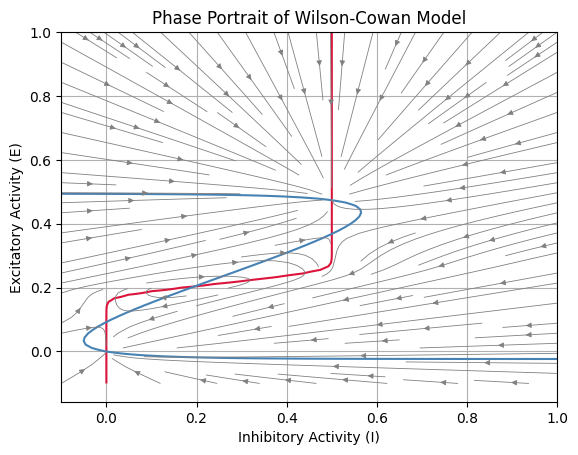

In [ ]:
#THEOREM 2
wc_parameters_2 = dict(r_e = 1, r_i = 1, a_e = 1.5, a_i = 6, theta_e = 2.5, theta_i = 4.3, c1 = 13, c2 = 4, c3 = 22, c4 = 2, P = 0, Q = 0)

E_points = np.linspace(-0.1, 1, 100)
I_points = np.linspace(-0.1, 1, 100)
I_grid, E_grid = np.meshgrid(I_points, E_points)

dI_grid, dE_grid = np.zeros_like(I_grid), np.zeros_like(I_grid)

for idx_1, I in enumerate(I_points):
  for idx_2, E in enumerate(E_points):

    dI, dE = wilson_cowan(0, [I, E], **wc_parameters_2)
    dI_grid[idx_2, idx_1], dE_grid[idx_2, idx_1] = dI, dE



fig, ax = plt.subplots()
ax.contour(I_grid, E_grid, dI_grid, levels = [0], colors = 'crimson')
ax.contour(I_grid, E_grid, dE_grid, levels = [0], colors = 'steelblue')
ax.streamplot(I_grid, E_grid, dI_grid, dE_grid, color='gray', density=1.2, linewidth=0.6, arrowsize=0.8)
plt.title('Phase Portrait of Wilson-Cowan Model')
plt.ylabel('Excitatory Activity (E)')
plt.xlabel('Inhibitory Activity (I)')
plt.grid(True)
plt.show()

/tmp/ipykernel_4496/1785945749.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_2), [i, e], full_output=False)
/tmp/ipykernel_4496/1785945749.py:15: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
 solution is possible.
  sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_2), [i, e], full_output=False)
/tmp/ipykernel_4496/1785945749.py:15: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_2), [i, e], full_output=False)
/tmp/ipykernel_4496/1407657938.py:2: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-a*(x-theta))) - 1/(1 + np.exp(a*theta))


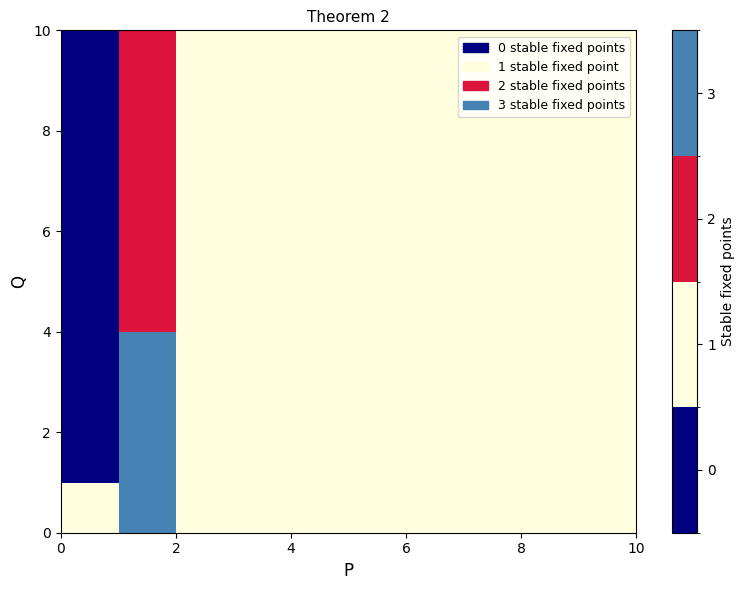

In [ ]:
c3_fixed = 25
c2_fixed = 4
final_parameters_2 = dict(r_e = 1, r_i = 1, a_e = 1.2, a_i = 5, theta_e = 2.7, theta_i = 3.7, c1 = 13, c4 = 2, c3 = 25, c2 = 4)
P = np.linspace(0, 10, 10)
Q = np.linspace(0, 10, 10)

E_values = np.linspace(0.01, 0.99, 100)
I_values = np.linspace(0.01, 0.99, 100)

def final_2(P, Q):
  fp = []

  for i in I_values:
    for e in E_values:
      sol = fsolve(lambda y: wilson_cowan(0, y, P=P, Q=Q, **final_parameters_2), [i, e], full_output=False)
      check = wilson_cowan(0, sol, P=P, Q=Q, **final_parameters_2)

      if np.max(np.abs(check)) > 1e-8:
        continue
      if np.any(sol < 0.001) or np.any(sol > 0.99):
        continue

      is_true = True
      for point in fp:
        if np.linalg.norm(sol - point) < 1e-3:
          is_true = False

      if is_true:
        fp.append(sol)


  return len(fp)

theorem_2_matrix = np.zeros((len(P), len(Q)))
for idx_1, q in enumerate(Q):
  for idx_2, p in enumerate(P):
    theorem_2_matrix[idx_1, idx_2] = final_2(p, q)


colors = ['navy', 'lightyellow', 'crimson', 'steelblue']
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    theorem_2_matrix,
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm=norm,
    extent=[P[0], P[-1],
            Q[0], Q[-1]]
)

patches = [
    mpatches.Patch(color='navy',       label='0 stable fixed points'),
    mpatches.Patch(color='lightyellow',label='1 stable fixed point'),
    mpatches.Patch(color='crimson',    label='2 stable fixed points'),
    mpatches.Patch(color='steelblue',    label='3 stable fixed points')
]
ax.legend(handles=patches, fontsize=9, loc='upper right')

ax.set_xlabel('P', fontsize=12)
ax.set_ylabel('Q', fontsize=12)
ax.set_title(f'Theorem 2',fontsize=11)
plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], label='Stable fixed points')
plt.tight_layout()
plt.show()

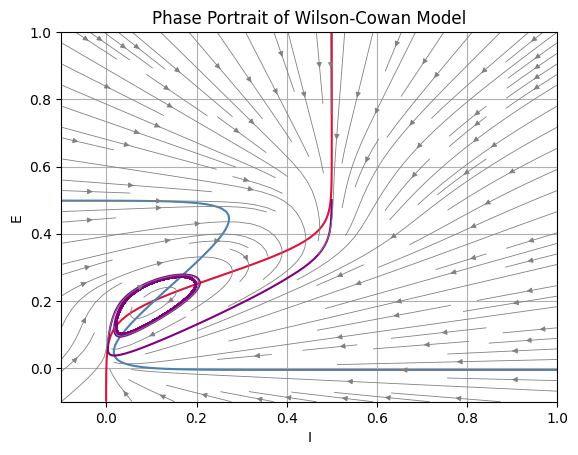

In [ ]:
#THEOREM 3
wc_parameters_3 = dict(r_e = 1, r_i = 1, a_e = 1.3, a_i = 2, theta_e = 4, theta_i = 3.7, c1 = 16, c2 = 12, c3 = 15, c4 = 3, P = 1.25, Q = 0)

E_points = np.linspace(-0.1, 1, 100)
I_points = np.linspace(-0.1, 1, 100)
I_grid, E_grid = np.meshgrid(I_points, E_points)

dI_grid, dE_grid = np.zeros_like(I_grid), np.zeros_like(I_grid)

for idx_1, I in enumerate(I_points):
  for idx_2, E in enumerate(E_points):

    dI, dE = wilson_cowan(0, [I, E], **wc_parameters_3)
    dI_grid[idx_2, idx_1], dE_grid[idx_2, idx_1] = dI, dE

initial_point = [0.5, 0.5]
t_span = [0, 200]
t_eval = np.linspace(0,200,5000)

wc_ode_func = functools.partial(wilson_cowan, **wc_parameters_3)

sol = solve_ivp(wc_ode_func, t_span, initial_point, t_eval=t_eval, method='RK45')

fig, ax = plt.subplots()
ax.contour(I_grid, E_grid, dI_grid, levels = [0], colors = 'crimson')
ax.contour(I_grid, E_grid, dE_grid, levels = [0], colors = 'steelblue')
ax.plot(sol.y[0], sol.y[1], color = 'purple')
ax.streamplot(I_points, E_points, dI_grid, dE_grid, color='gray', density=1.2, linewidth=0.6, arrowsize=0.8)
plt.title('Phase Portrait of Wilson-Cowan Model')
plt.xlabel('I')
plt.ylabel('E')
plt.grid(True)
plt.show()

P = 3.1578947368421053, Q = 2.631578947368421, Diff = 0.4121511983978391
P = 3.1578947368421053, Q = 3.1578947368421053, Diff = 0.4524906145014047
P = 3.6842105263157894, Q = 3.1578947368421053, Diff = 0.4384570414523592
P = 3.1578947368421053, Q = 3.6842105263157894, Diff = 0.475303690250405
P = 3.6842105263157894, Q = 3.6842105263157894, Diff = 0.4714973666288641
P = 3.1578947368421053, Q = 4.2105263157894735, Diff = 0.4853875233433622
P = 3.6842105263157894, Q = 4.2105263157894735, Diff = 0.48838405641755245
P = 3.1578947368421053, Q = 4.7368421052631575, Diff = 0.4889765391219083
P = 3.6842105263157894, Q = 4.7368421052631575, Diff = 0.4950112933052664
P = 3.1578947368421053, Q = 5.263157894736842, Diff = 0.4901024439542204
P = 3.6842105263157894, Q = 5.263157894736842, Diff = 0.4971940622938889
P = 4.2105263157894735, Q = 5.263157894736842, Diff = 0.4989611407775515
P = 3.1578947368421053, Q = 5.789473684210526, Diff = 0.49045212261536697
P = 3.6842105263157894, Q = 5.789473684210

/tmp/ipykernel_4496/1137079567.py:66: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='lightyellow', edgecolor='gray',


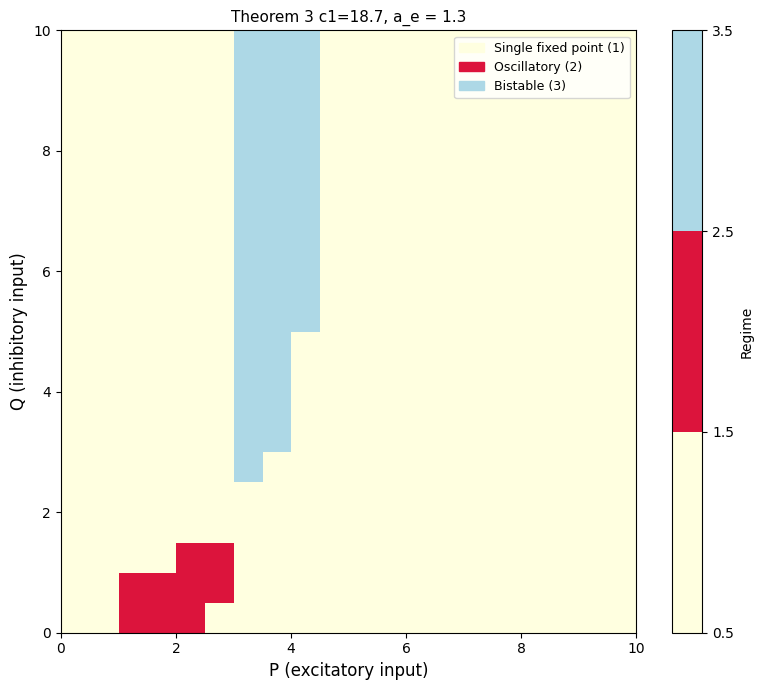

In [ ]:
def oscillations(sol, dt=1):
  E = sol.y[1][3000:]

  amplitude = np.max(E) - np.min(E)
  return amplitude


fixed_parameters_3_A = dict(r_e = 1, r_i = 1, a_e = 1.3, a_i = 2, theta_e = 4, theta_i = 3.7, c1 = 18.7, c2 = 12, c3 = 15, c4 = 3)

t_span = (0, 500)
t_eval = np.linspace(0, 500, 5000)

P_range = np.linspace(0, 10, 20)
Q_range = np.linspace(0, 10, 20)

inital_point_1 = [0.01,0.01]
inital_point_2 = [0.95, 0.95]

theorem_3_matrix_A = np.zeros((len(Q_range), len(P_range)))

for idx1, Q in enumerate(Q_range):
  for idx2, P in enumerate(P_range):
    sol1 = solve_ivp(lambda t,y,P=P, Q=Q: wilson_cowan(t,y,P=P, Q=Q, **fixed_parameters_3_A), t_span, inital_point_1, t_eval=t_eval)
    sol2 = solve_ivp(lambda t,y,P=P, Q=Q: wilson_cowan(t,y,P=P, Q=Q, **fixed_parameters_3_A), t_span, inital_point_2, t_eval=t_eval)

    amp1 = oscillations(sol1)
    amp2 = oscillations(sol2)

    mean1 = np.mean(sol1.y[1][3000:])
    mean2 = np.mean(sol2.y[1][3000:])
    diff = abs(mean1 - mean2)
    if diff > 0.05:
      print(f"P = {P}, Q = {Q}, Diff = {diff}")

    if (amp1 > 0.05) or (amp2 > 0.05):
      theorem_3_matrix_A[idx1, idx2] = 2
    elif np.abs(mean1 - mean2) > 0.1:
      theorem_3_matrix_A[idx1, idx2] = 3
    else:
      theorem_3_matrix_A[idx1, idx2] = 1




colors = ['lightyellow', 'crimson', 'lightblue']
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    theorem_3_matrix_A,
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm = norm,
    extent=[P_range[0], P_range[-1],
            Q_range[0], Q_range[-1]]
)


patches = [
    mpatches.Patch(color='lightyellow', edgecolor='gray',
                   label='Single fixed point (1)'),
    mpatches.Patch(color='crimson',
                   label='Oscillatory (2)'),
    mpatches.Patch(color='lightblue',
                   label='Bistable (3)'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')

ax.set_xlabel('P (excitatory input)', fontsize=12)
ax.set_ylabel('Q (inhibitory input)', fontsize=12)
ax.set_title('Theorem 3 c1=18.7, a_e = 1.3',
             fontsize=11)

plt.colorbar(im, ax=ax, label='Regime')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4496/818094329.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='lightyellow', edgecolor='gray',


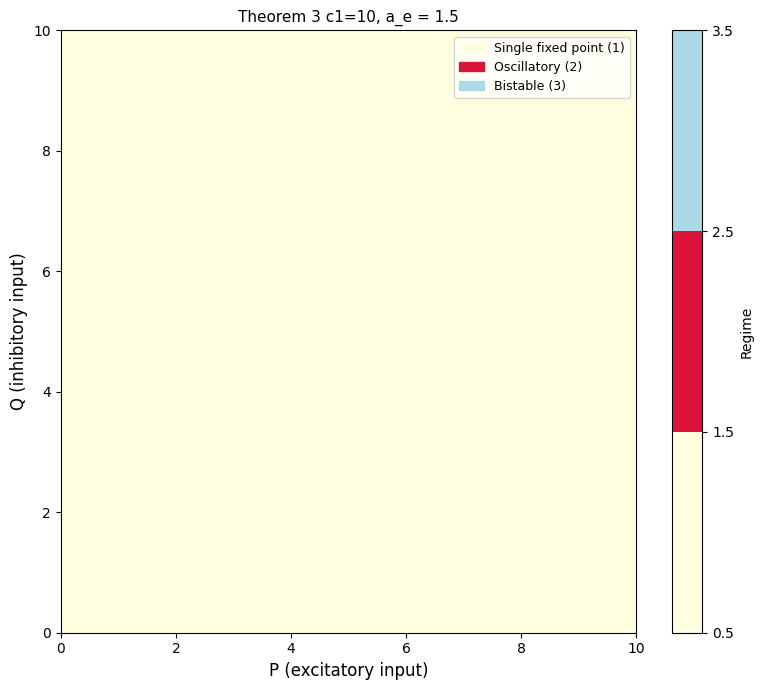

In [ ]:
fixed_parameters_3_B = dict(r_e = 1, r_i = 1, a_e = 1.5, a_i = 2, theta_e = 4, theta_i = 3.7, c1 = 10, c2 = 12, c3 = 15, c4 = 3)

t_span = (0, 500)
t_eval = np.linspace(0, 500, 5000)

P_range = np.linspace(0, 10, 20)
Q_range = np.linspace(0, 10, 20)

inital_point_1 = [0.01,0.01]
inital_point_2 = [0.95, 0.95]

theorem_3_matrix_B = np.zeros((len(Q_range), len(P_range)))

for idx1, Q in enumerate(Q_range):
  for idx2, P in enumerate(P_range):
    sol1 = solve_ivp(lambda t,y,P=P, Q=Q: wilson_cowan(t,y,P=P, Q=Q, **fixed_parameters_3_B), t_span, inital_point_1, t_eval=t_eval)
    sol2 = solve_ivp(lambda t,y,P=P, Q=Q: wilson_cowan(t,y,P=P, Q=Q, **fixed_parameters_3_B), t_span, inital_point_2, t_eval=t_eval)

    amp1 = oscillations(sol1)
    amp2 = oscillations(sol2)

    mean1 = np.mean(sol1.y[1][3000:])
    mean2 = np.mean(sol2.y[1][3000:])
    diff = abs(mean1 - mean2)
    if diff > 0.05:
      print(f"P = {P}, Q = {Q}, Diff = {diff}")

    if (amp1 > 0.05) or (amp2 > 0.05):
      theorem_3_matrix_B[idx1, idx2] = 2
    elif np.abs(mean1 - mean2) > 0.1:
      theorem_3_matrix_B[idx1, idx2] = 3
    else:
      theorem_3_matrix_B[idx1, idx2] = 1




colors = ['lightyellow', 'crimson', 'lightblue']
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    theorem_3_matrix_B,
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm = norm,
    extent=[P_range[0], P_range[-1],
            Q_range[0], Q_range[-1]]
)


patches = [
    mpatches.Patch(color='lightyellow', edgecolor='gray',
                   label='Single fixed point (1)'),
    mpatches.Patch(color='crimson',
                   label='Oscillatory (2)'),
    mpatches.Patch(color='lightblue',
                   label='Bistable (3)'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')

ax.set_xlabel('P (excitatory input)', fontsize=12)
ax.set_ylabel('Q (inhibitory input)', fontsize=12)
ax.set_title('Theorem 3 c1=10, a_e = 1.5',
             fontsize=11)

plt.colorbar(im, ax=ax, label='Regime')
plt.tight_layout()
plt.show()

P = 3.1578947368421053, Q = 2.631578947368421, Diff = 0.4121511983978391
P = 3.1578947368421053, Q = 3.1578947368421053, Diff = 0.4524906145014047
P = 3.6842105263157894, Q = 3.1578947368421053, Diff = 0.4384570414523592
P = 3.1578947368421053, Q = 3.6842105263157894, Diff = 0.475303690250405
P = 3.6842105263157894, Q = 3.6842105263157894, Diff = 0.4714973666288641
P = 3.1578947368421053, Q = 4.2105263157894735, Diff = 0.4853875233433622
P = 3.6842105263157894, Q = 4.2105263157894735, Diff = 0.48838405641755245
P = 3.1578947368421053, Q = 4.7368421052631575, Diff = 0.4889765391219083
P = 3.6842105263157894, Q = 4.7368421052631575, Diff = 0.4950112933052664
P = 3.1578947368421053, Q = 5.263157894736842, Diff = 0.4901024439542204
P = 3.6842105263157894, Q = 5.263157894736842, Diff = 0.4971940622938889
P = 4.2105263157894735, Q = 5.263157894736842, Diff = 0.4989611407775515
P = 3.1578947368421053, Q = 5.789473684210526, Diff = 0.49045212261536697
P = 3.6842105263157894, Q = 5.789473684210

/tmp/ipykernel_4496/3421124402.py:57: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='lightyellow', edgecolor='gray',


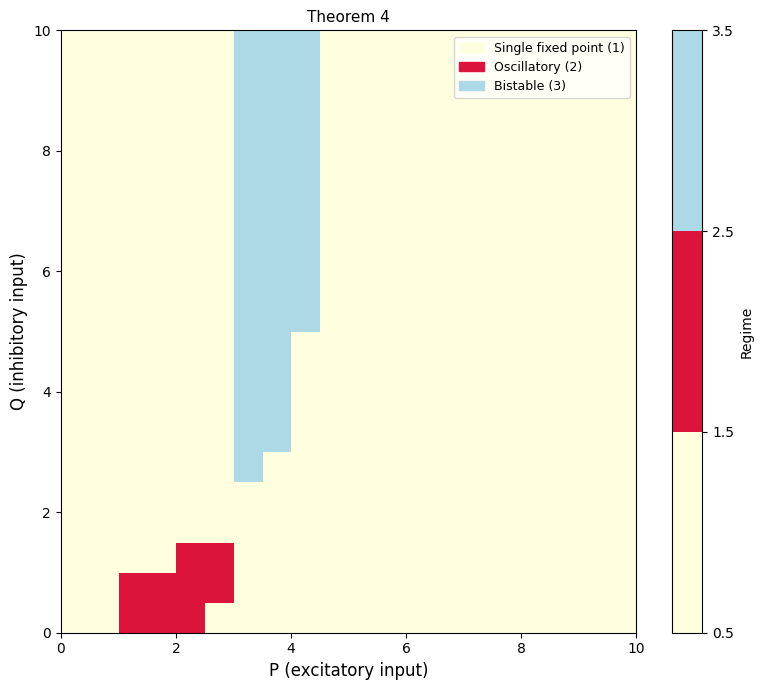

In [ ]:
#Theorem 4
fixed_parameters_4 = dict(r_e = 1, r_i = 1, a_e = 1.3, a_i = 2, theta_e = 4, theta_i = 3.7, c1 = 18.7, c2 = 12, c3 = 15, c4 = 3)

t_span = (0, 500)
t_eval = np.linspace(0, 500, 5000)

P_range = np.linspace(0, 10, 20)
Q_range = np.linspace(0, 10, 20)

inital_point_1 = [0.01,0.01]
inital_point_2 = [0.95, 0.95]

theorem_4_matrix = np.zeros((len(Q_range), len(P_range)))

for idx1, Q in enumerate(Q_range):
  for idx2, P in enumerate(P_range):
    sol1 = solve_ivp(lambda t,y,P=P, Q=Q: wilson_cowan(t,y,P=P, Q=Q, **fixed_parameters_4), t_span, inital_point_1, t_eval=t_eval)
    sol2 = solve_ivp(lambda t,y,P=P, Q=Q: wilson_cowan(t,y,P=P, Q=Q, **fixed_parameters_4), t_span, inital_point_2, t_eval=t_eval)

    amp1 = oscillations(sol1)
    amp2 = oscillations(sol2)

    mean1 = np.mean(sol1.y[1][3000:])
    mean2 = np.mean(sol2.y[1][3000:])
    diff = abs(mean1 - mean2)
    if diff > 0.05:
      print(f"P = {P}, Q = {Q}, Diff = {diff}")

    if (amp1 > 0.05) or (amp2 > 0.05):
      theorem_4_matrix[idx1, idx2] = 2
    elif np.abs(mean1 - mean2) > 0.1:
      theorem_4_matrix[idx1, idx2] = 3
    else:
      theorem_4_matrix[idx1, idx2] = 1



colors = ['lightyellow', 'crimson', 'lightblue']
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    theorem_4_matrix,
    origin='lower',
    aspect='auto',
    cmap=cmap,
    norm = norm,
    extent=[P_range[0], P_range[-1],
            Q_range[0], Q_range[-1]]
)


patches = [
    mpatches.Patch(color='lightyellow', edgecolor='gray',
                   label='Single fixed point (1)'),
    mpatches.Patch(color='crimson',
                   label='Oscillatory (2)'),
    mpatches.Patch(color='lightblue',
                   label='Bistable (3)'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')

ax.set_xlabel('P (excitatory input)', fontsize=12)
ax.set_ylabel('Q (inhibitory input)', fontsize=12)
ax.set_title('Theorem 4',
             fontsize=11)

plt.colorbar(im, ax=ax, label='Regime')
plt.tight_layout()
plt.show()